In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv", index_col=0)
df

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,,,,,,,,
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.340,27,0
5,121,72,23,112,26.2,0.245,30,0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [57]:
df = df.drop('Outcome', axis=1)
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,,,,,,,
6,148,72,35,0,33.6,0.627,50
1,85,66,29,0,26.6,0.351,31
8,183,64,0,0,23.3,0.672,32
1,89,66,23,94,28.1,0.167,21
0,137,40,35,168,43.1,2.288,33


In [59]:
X = df.drop('BMI', axis=1)
X.head()

,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
Pregnancies,,,,,,
6,148,72,35,0,0.627,50
1,85,66,29,0,0.351,31
8,183,64,0,0,0.672,32
1,89,66,23,94,0.167,21
0,137,40,35,168,2.288,33


In [43]:
y=df['BMI']
y.head()

,BMI
Pregnancies,
6,33.6
1,26.6
8,23.3
1,28.1
0,43.1


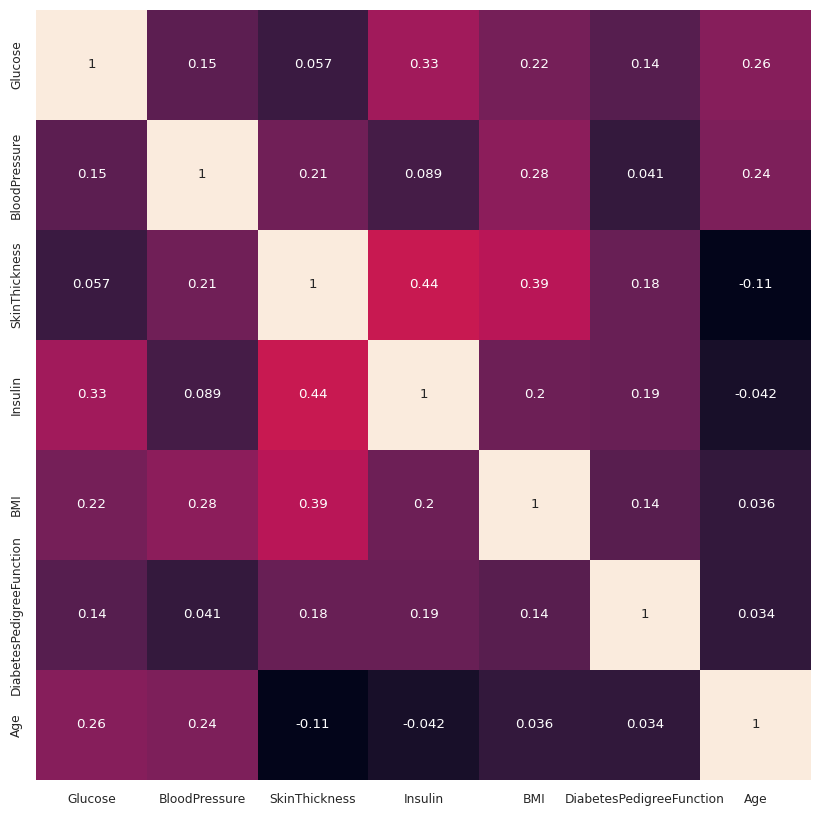

In [66]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

#BMI 와 상관이 높은건 skinthickness

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)



(614, 6)
(154, 6)


In [63]:
#Regression

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 52.10225730069578
평균제곱근오차 52.10225730069578
평균제곱근오차 52.1022573006958


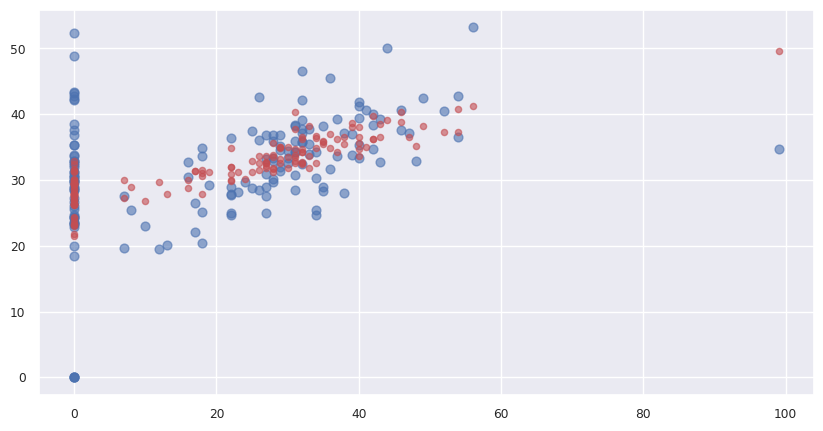

In [75]:
#LinearRegression 모델
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(X_test['SkinThickness'], y_test, label='Actual', alpha=0.6, s=40)
plt.scatter(X_test['SkinThickness'], ly_preds, c='r', label='Predicted', alpha=0.6, s=20)
#plt.plot(X_train, ly.predict(X_train), color='blue')
plt.show()

In [76]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test))

평균제곱근오차 96.90974025974025


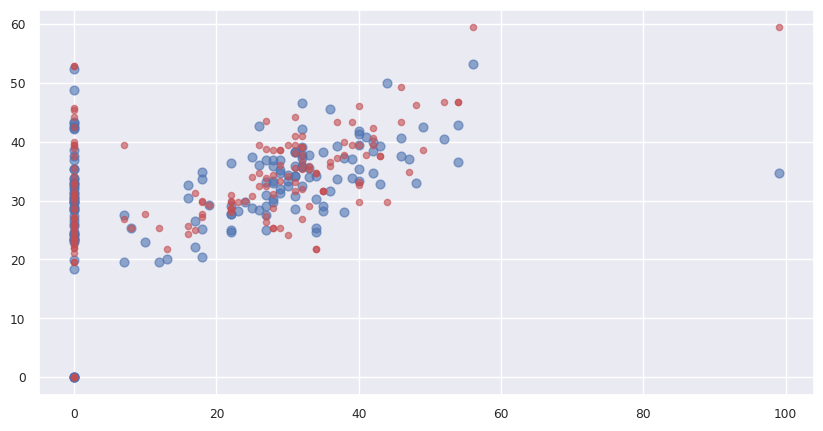

In [77]:
#DecisionTreeRegressor 모델
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(X_test['SkinThickness'], y_test, label='Actual', alpha=0.6, s=40)
plt.scatter(X_test['SkinThickness'], dy_preds, c='r', label='Predicted', alpha=0.6, s=20)
#plt.plot(X_train, ly.predict(X_train), color='blue')
plt.show()

In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

평균제곱근오차 48.947704701298754


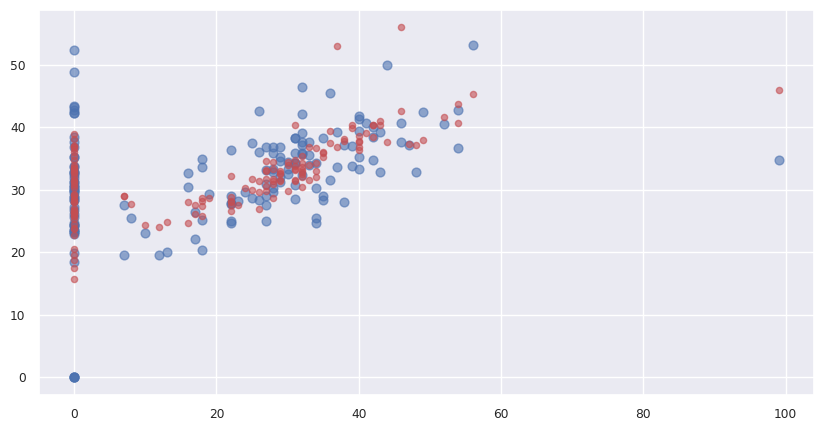

In [80]:
#RandomForestRegressor 모델

plt.figure(figsize=(10,5))
plt.scatter(X_test['SkinThickness'], y_test, label='Actual', alpha=0.6, s=40)
plt.scatter(X_test['SkinThickness'], ry_preds, c='r', label='Predicted', alpha=0.6, s=20)
#plt.plot(X_train, ly.predict(X_train), color='blue')
plt.show()

In [82]:
#번외

from sklearn.svm import SVR

model = SVR(kernel='linear')
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error
sy_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(sy_preds, y_test))

평균제곱근오차 52.83723881883655


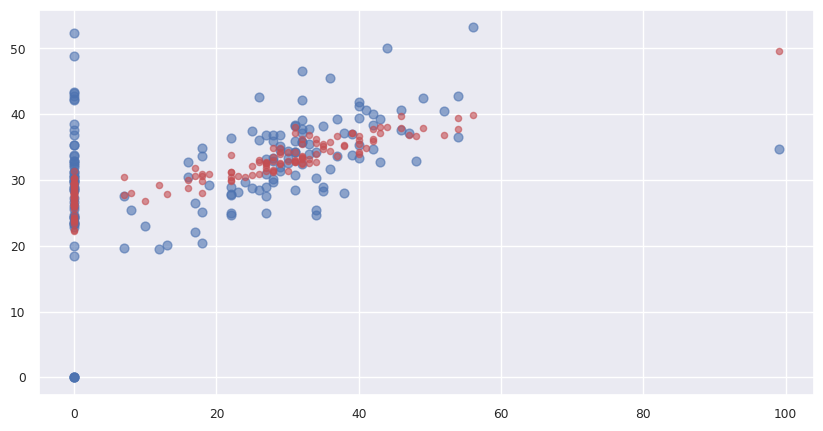

In [83]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['SkinThickness'], y_test, label='Actual', alpha=0.6, s=40)
plt.scatter(X_test['SkinThickness'], sy_preds, c='r', label='Predicted', alpha=0.6, s=20)
#plt.plot(X_train, ly.predict(X_train), color='blue')
plt.show()